# PedSilicoICH: Part 1. Phantoms

This notebook introduces the features and uses of the PedSilicoICH tool for generating anthropomorphic ground truth phantoms - currently based on the MIDA phantom and NIHPD MR brain atlases as a base - with models of intracranial hemorrhage, specifically intraparenchymal (IPH), epiural (EDH), and subural (SDH) hemorrages.liver metastases.

This notebook also introduces concepts of the `Phantoms` Class

## Select a starting phantom

In [1]:
import VITools
available_phantoms = VITools.get_available_phantoms()
available_phantoms

{'0.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=0.0, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/UNC_Head_phantom')),
 '1.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=1.0, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/UNC_Head_phantom')),
 '2.0 yr UNC Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.UNC_Head'>, age=2.0, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/UNC_Head_phantom')),
 '6.5 yr NIHPD Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.NIHPD_Head'>, age=6.5, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/NIHPD_Head_Phantom')),
 '9.0 yr NIHPD Head': functools.partial(<class 'insilicoICH.phantoms.head_phantoms.NIHPD_Head'>, age=9.0, phantom_dir=PosixPath('/projects01/didsr-aiml/common_data/pedsilicoich/NIHPD_Head_Phantom')),
 '10.5 yr NIHPD He

In [2]:
phantom = available_phantoms['2.0 yr UNC Head']()
phantom


        Phantom Class: UNC_Head
        Age (years): 2.0
        Shape (voxels): (181, 217, 181)
        Size (mm): (181.0, 217.0, 181.0)
        
Number of lesions: 0

In [2]:
from insilicoICH.lesion_definition import LesionFactory
phantom = available_phantoms['6.5 yr NIHPD Head']()
# shape = 3*[128]
# phantom.resize(shape)
lesion = LesionFactory.create('IPH', spacings=phantom.spacings, boundary=phantom.get_material_mask('white matter'), seed=307835)
lesion.generate(volume_ml=2, intensity_hu=50, texture_scale=6, texture_contrast=1,
               complexity=3, smoothness=0.2, irregularity=0.5, eccentricity=0.6, edema_thickness=2)
phantom.insert_lesion(lesion, mass_effect=0.5)

lesion = LesionFactory.create('IPH', spacings=phantom.spacings, boundary=phantom.get_material_mask('white matter'), seed=42)
lesion.generate(volume_ml=2, intensity_hu=50, texture_scale=20, texture_contrast=1,
                complexity=3, smoothness=0.2, irregularity=0.5, eccentricity=0.6, edema_thickness=5)
phantom.insert_lesion(lesion, mass_effect=0.5)

pseudo-CT images not found; defaulting to otsu segmentation method



        Phantom Class: NIHPD_Head
        Age (years): 6.5
        Shape (voxels): (189, 233, 197)
        Size (mm): (151.2, 186.4, 157.6)
        
Number of lesions: 2
  - Lesion 1: IPH, Volume: 2.00 mL, Center: (62, 82, 110)
Mass effect strength: 0.5  - Lesion 2: IPH, Volume: 2.00 mL, Center: (76, 73, 84)
Mass effect strength: 0.5

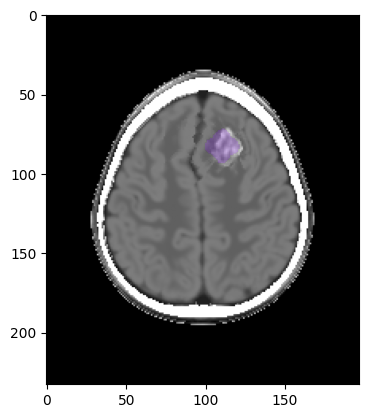

In [3]:
import matplotlib.pyplot as plt
import numpy as np

lesion_idx = 0
z_slice = phantom.lesions[lesion_idx].coords_voxel[0]
plt.imshow(phantom.get_CT_number_phantom()[z_slice], cmap='gray', vmin=0, vmax=80)
lesion_mask = phantom.lesions[lesion_idx].mask[z_slice]
plt.imshow(np.ma.masked_where(lesion_mask == 0, lesion_mask), cmap='rainbow', alpha=0.2)

In [4]:
from monai.transforms import RandAffine

transform = RandAffine(
    prob=1.0,
    rotate_range=[np.pi/4, np.pi/20, np.pi/20],
    translate_range=[10, 10, 10],
    scale_range=[0.1, 0.1, 0.1],
    padding_mode="border",
    mode='nearest'
)
phantom.apply_transform(transform)

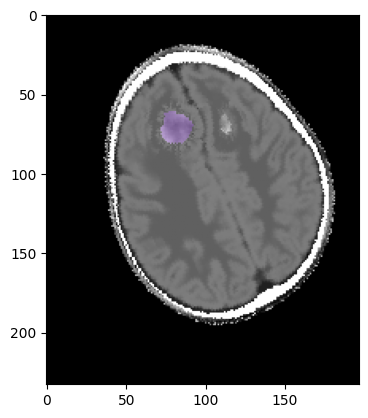

In [5]:
import matplotlib.pyplot as plt
import numpy as np

lesion_idx = 1
z_slice = phantom.lesions[lesion_idx].coords_voxel[0]
plt.imshow(phantom.get_CT_number_phantom()[z_slice], cmap='gray', vmin=0, vmax=80)
lesion_mask = phantom.lesions[lesion_idx].mask[z_slice]
plt.imshow(np.ma.masked_where(lesion_mask == 0, lesion_mask), cmap='rainbow', alpha=0.2)

Need to start *measuring texture* from real images

In [6]:
from utils import scrollview

scrollview(phantom.get_CT_number_phantom(), 'brain')

interactive(children=(IntSlider(value=94, description='idx', max=188), Output()), _dom_classes=('widget-intera…

In [12]:
scrollview(phantom.get_CT_number_phantom().numpy().transpose(2, 0, 1), 'brain')

interactive(children=(IntSlider(value=98, description='idx', max=196), Output()), _dom_classes=('widget-intera…

from utils import load_phantom
from tqdm import tqdm
import pandas as pd
import numpy as np

target_vol = [1, 5, 10, 15]
lesions = ['IPH', 'EDH', 'SDH']
n_lesions = 10
ages = [6.5]

targets = []
measured = []
lesion_type = []
patient_age = []
z_coords = []

total = len(target_vol) * len(lesions) * n_lesions * len(ages)
pbar = tqdm(total=total)
for age in ages:
    for lesion in lesions:
        phantom = load_phantom(age)
        count = 0
        for target in target_vol:
            for _ in range(n_lesions):
                phantom.insert_lesion(lesion, mass_effect=False, intensity=40, volume=target)
                targets.append(target)
                measured.append(phantom.lesions[count].volume_ml)
                z_coords.append(phantom.lesions[count].coords_voxel[0])
                lesion_type.append(lesion)
                patient_age.append(age)
                pbar.update(1)
                count += 1
pbar.close()
df = pd.DataFrame({
    'Patient Age': age,
    'Lesion Type': lesion_type,
    'desired': np.stack(targets),
    'measured': np.stack(measured),
    'Z Center': np.stack(z_coords)
    })
df

df['desired'].min()

import seaborn as sns
f, ax = plt.subplots(figsize=(4,3), dpi=150)
sns.scatterplot(data=df, x='desired', y='measured', style='Patient Age', hue='Lesion Type')
plt.plot([df['desired'].min(), df['desired'].max()], [df['desired'].min(), df['desired'].max()], label='ideal', color='black')
plt.legend()

sns.histplot(data=df, x='Z Center', hue='Lesion Type')

In [13]:
from utils import scrollview

scrollview(phantom.get_CT_number_phantom(), 'brain')

interactive(children=(IntSlider(value=94, description='idx', max=188), Output()), _dom_classes=('widget-intera…

In [14]:
phantom = available_phantoms['6.5 yr NIHPD Head']()

lesion = LesionFactory.create('IPH', spacings=phantom.spacings, boundary=phantom.get_material_mask('white matter'), seed=307835)
lesion.generate(volume_ml=2, intensity_hu=50, texture_scale=1, texture_contrast=2,
               complexity=3, smoothness=0.2, irregularity=0.5, eccentricity=0.6, edema_thickness=2)
phantom.insert_lesion(lesion, mass_effect=0.5)

lesion.generate(volume_ml=2, intensity_hu=50, texture_scale=1, texture_contrast=4,
               complexity=3, smoothness=0.2, irregularity=0.5, eccentricity=0.6, edema_thickness=2)
phantom.insert_lesion(lesion, mass_effect=0.5)

lesion.generate(volume_ml=2, intensity_hu=50, texture_scale=1, texture_contrast=16,
               complexity=3, smoothness=0.2, irregularity=0.5, eccentricity=0.6, edema_thickness=2)
phantom.insert_lesion(lesion, mass_effect=0.5)

# phantom.insert_lesion('IPH', mass_effect=0.5, intensity=50, volume=2, complexity=3,
#                       smoothness=0.2, irregularity=0.5, eccentricity=0.6, edema=2,
#                       seed=1, texture_kwargs=dict(noise_type='perlin', contrast_std=1, scale=1))
# phantom.insert_lesion('IPH', mass_effect=0.5, intensity=50, volume=2, complexity=3,
#                       smoothness=0.2, irregularity=0.5, eccentricity=0.6, edema=2,
#                       seed=2, texture_kwargs=dict(noise_type='perlin', contrast_std=1, scale=4))
# phantom.insert_lesion('IPH', mass_effect=0.5, intensity=50, volume=2, complexity=3,
#                       smoothness=0.2, irregularity=0.5, eccentricity=0.6, edema=2,
#                       seed=3, texture_kwargs=dict(noise_type='perlin', contrast_std=1, scale=16))

pseudo-CT images not found; defaulting to otsu segmentation method



        Phantom Class: NIHPD_Head
        Age (years): 6.5
        Shape (voxels): (189, 233, 197)
        Size (mm): (151.2, 186.4, 157.6)
        
Number of lesions: 3
  - Lesion 1: IPH, Volume: 2.00 mL, Center: (83, 124, 47)
Mass effect strength: 0.5  - Lesion 2: IPH, Volume: 2.00 mL, Center: (83, 124, 47)
Mass effect strength: 0.5  - Lesion 3: IPH, Volume: 2.00 mL, Center: (83, 124, 47)
Mass effect strength: 0.5

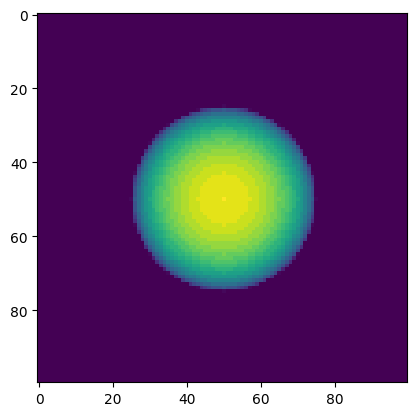

In [27]:
plt.imshow(phantom.get_CT_number_phantom().mean(axis=0))

In [26]:
scanner.recon.mean()

np.float32(-996.79645)

In [22]:
from utils import ctshow
# from measures import calculate_nps_3d
# volume = phantom.get_CT_number_phantom()

# f, axs = plt.subplots(1, len(phantom.lesions) + 1, gridspec_kw=dict(hspace=0, wspace=0))
# for idx, ax in enumerate(axs):
#     if idx < len(phantom.lesions):
#         mask = phantom.lesions[idx].mask
#         ctshow(volume[phantom.lesions[idx].coords_voxel[0]], 'brain', fig=f, ax=ax)
#     nps_3d = calculate_nps_3d(volume - volume[mask].mean(), mask)
#     center_y = nps_slice.shape[0] // 2
#     nps_profile = nps_slice[center_y, :]
#     axs[len(phantom.lesions)].plot(nps_profile)

In [23]:
volume = phantom.get_CT_number_phantom()

mask = phantom.lesions[0].mask
center = phantom.lesions[0].coords_voxel

nps_3d = calculate_nps_3d(volume, mask)

plt.figure(figsize=(12, 5))

# Plot the original volume slice with mask overlay
plt.subplot(1, 3, 1)
plt.imshow(volume[center[0], :, :], cmap='gray', vmin=0, vmax=80)
plt.imshow(mask[center[0], :, :], cmap='Reds', alpha=0.2)
plt.title("Central Slice of Volume with Mask")
plt.xlabel("X")
plt.ylabel("Y")

# Plot the NPS slice
plt.subplot(1, 3, 2)
# Use a logarithmic scale to better visualize the frequency components
plt.imshow(np.log(1 + nps_slice), cmap='viridis', origin='lower')
plt.title(f"Central 2D Slice of 3D NPS (log scale)")
plt.xlabel("Frequency X")
plt.ylabel("Frequency Y")
plt.colorbar(label="Log(Power)")

# Plot a 1D profile of the NPS slice
plt.subplot(1, 3, 3)
center_y = nps_slice.shape[0] // 2
nps_profile = nps_slice[center_y, :]
plt.plot(nps_profile)
plt.title("1D NPS Profile (Central Row)")
plt.xlabel("Frequency X")
plt.ylabel("Power")
plt.grid(True)

plt.tight_layout()
plt.show()

AttributeError: 'Phantom' object has no attribute 'lesions'

In [ ]:
from utils import ctshow
ctshow(phantom._phantom[67])

In [ ]:
phantom = available_phantoms['38.0 yr MIDA Head']()
phantom.resize(3*[240], mode='nearest')
phantom.insert_lesion('IPH', mass_effect=0.1, seed=42, intensity=80, volume=10,
                      texture_kwargs=dict(noise_type='perlin', contrast_std=2),
                      edema=2)

In [ ]:
from utils import ctshow
ctshow(phantom.get_CT_number_phantom()[63], 'soft tissues')

%pip install -q ipywidgets

In [ ]:
from utils import scrollview

scrollview(phantom.get_CT_number_phantom())

## define a set of lesions to insert
This can be done individual or arranged into a list if inserting multiple as demonstrated here.

In [ ]:
import numpy as np
volumes = np.linspace(0.05, 0.5, 3)
intensities = np.linspace(70, 50, 3)
lesion_type = 'IPH'

lesions = []
for intensity, volume in zip(intensities, volumes):
    lesion_definition = dict(
        volume=volume,
        intensity=intensity,
        lesion_type=lesion_type,
        mass_effect=0.1,  # optional
        seed=336  # optional for reproducibility
    )
    lesions.append(lesion_definition)
lesions

## Insert the lesions into the selected phantom

In [ ]:
for idx, lesion in enumerate(lesions):
    print(f'inserting lesion {idx}/{len(lesions)}:\n{lesion}\n')
    phantom.insert_lesion(**lesion)

phantom

Checkout the results

In [ ]:
%pip install -q matplotlib ipywidgets

TODO: Next add some simple options to add random amounts of scale, controlling decay factor of mass effect and contrast_std

Contrast STD (heterogeneity) related to time since stroke 

Decay/strength of mass effect related to swelling/edema etc

Also add some unit tests for mass effect

In [ ]:
from utils import scrollview, show_lesions
show_lesions(phantom, 'brain')

In [ ]:
# pip install -q noise

In [ ]:
scrollview(phantom.get_CT_number_phantom())

In [ ]:
import matplotlib.pyplot as plt
if hasattr(phantom, 'get_sutures'):
    sutures = phantom.get_sutures()
    f, axs = plt.subplots(1, 3)
    for dim, ax in enumerate(axs.flatten()):
        ax.imshow(sutures.max(axis=dim))

Some simple analytical geometric lesions are included in the module `lesion_insertion`, see the help string for more details

Need to revisit mass effect for UNC to make sure its working there too

In [ ]:
from utils import ctshow, load_phantom

seed = 88
age = 6.5
vol = 10
display = 'brain'

phantom = load_phantom(age)
phantom.insert_lesion('EDH', volume=vol, mass_effect=False, seed=seed)
phantom_no_me_image = phantom.get_CT_number_phantom()[phantom.lesions[0].coords_voxel[0]]

f, axs = plt.subplots(3, 3, dpi=150, gridspec_kw=dict(hspace=0, wspace=0))

for row, me in zip(axs, [0, 0.5, 1]):

    phantom_me = load_phantom(age)
    phantom_me.insert_lesion('EDH', volume=vol, mass_effect=me, seed=seed)
    phantom_me_image = phantom_me.get_CT_number_phantom()[phantom_me.lesions[0].coords_voxel[0]]

    ctshow(phantom.get_CT_number_phantom()[phantom.lesions[0].coords_voxel[0]], display, fig=f, ax=row[0])
    ctshow(phantom_me.get_CT_number_phantom()[phantom_me.lesions[0].coords_voxel[0]], display, fig=f, ax=row[1])
    row[2].imshow(phantom_me_image - phantom_no_me_image, vmin=-20, vmax=20)
    row[2].set_xticks([])
    row[2].set_yticks([])

In [ ]:
phantom = load_phantom(age)
phantom.insert_lesion('EDH', volume=vol, mass_effect=False, seed=seed)
phantom_no_me_image = phantom.get_CT_number_phantom()[phantom.lesions[0].coords_voxel[0]]

f, axs = plt.subplots(3, 3, dpi=150, gridspec_kw=dict(hspace=0, wspace=0))

for row, vol in zip(axs, [5, 10, 20]):

    phantom_me = load_phantom(age)
    phantom_me.insert_lesion('EDH', volume=vol, mass_effect=1.0, seed=seed)
    phantom_me_image = phantom_me.get_CT_number_phantom()[phantom_me.lesions[0].coords_voxel[0]]

    ctshow(phantom.get_CT_number_phantom()[phantom.lesions[0].coords_voxel[0]], display, fig=f, ax=row[0])
    ctshow(phantom_me.get_CT_number_phantom()[phantom_me.lesions[0].coords_voxel[0]], display, fig=f, ax=row[1])
    row[2].imshow(phantom_me_image - phantom_no_me_image, vmin=-20, vmax=20)
    row[2].set_xticks([])
    row[2].set_yticks([])

In [ ]:
plt.imshow(phantom.get_CT_number_phantom()[phantom.lesions[0].coords_voxel[0]], cmap='gray')
plt.imshow(phantom.warp_inclusion_mask[phantom.lesions[0].coords_voxel[0]], cmap='Blues', alpha=0.3)
plt.imshow(phantom.warp_exclusion_mask[phantom.lesions[0].coords_voxel[0]], cmap='Reds', alpha=0.3)

Each lesion type has its own specific method, `add_<lesion_type>`, checkout the help string of each for more details

### Intraparenchymal (round)

In [ ]:
phantom.add_round_lesion?

In [ ]:
volume = 6
intensity = 100
phantom = load_phantom(38.0)
phantom.resize(shape=phantom.shape, mode='nearest')
phantom.insert_lesion('IPH', volume, intensity=intensity,
                      complexity=3, edema=7, eccentricity=0.1,
                      mass_effect=1.0) 
show_lesions(phantom)

In [ ]:
volume = 6
intensity = 60
phantom = load_phantom(age)
phantom.insert_lesion('IPH', volume, intensity=intensity,
                      complexity=3, edema=7, eccentricity=0.1,
                      mass_effect=False)
show_lesions(phantom)

### Subdural (SDH)

In [ ]:
volume = 20
phantom = load_phantom(age)
phantom.insert_lesion('SDH', volume, intensity=intensity, mass_effect=1.0) 
show_lesions(phantom, 'subdural')

### Epidural (EDH)

In [ ]:
volume = 20
phantom = load_phantom(age)
phantom.insert_lesion('EDH', volume, intensity=intensity, mass_effect=1.0) 
show_lesions(phantom, 'brain')

### Multiple (TODO: ensure no overlapping of hemorrhages)

In [ ]:
seed = 32
mass_effect = 0.5
phantom = load_phantom(age)
intensity = 60
phantom.insert_lesion('IPH', volume=3, intensity=intensity, seed=seed, mass_effect=mass_effect) 
phantom.insert_lesion('SDH', volume, intensity=intensity, seed=seed, mass_effect=mass_effect) 
phantom.insert_lesion('EDH', volume, intensity=intensity, seed=seed, mass_effect=mass_effect) 

show_lesions(phantom,'brain')

In [ ]:
phantom

In [ ]:
lesions = phantom.get_lesion_mask()
lesions.shape

`phantom._lesion_coords` is a list of (z,x,y) coordinates of the inserted lesion, you can check the `len` to see how many lesions have been inserted, thus by indexing `[0][0]` we are taking the z index of the first lesion.

In [ ]:
phantom._lesion_coords

Note that rerunning the following cell, you can keep adding lesions to a phantom

In [ ]:
from monai.transforms import RandAffine

add_positioning_augmentation = True
if add_positioning_augmentation:
    positioning_transform = RandAffine(prob=1, rotate_range = [np.pi/4, np.pi/20, np.pi/20], translate_range=[10, 10, 10], scale_range=[0.1, 0.1, 0.1], padding_mode="border")
else:
    positioning_transform = RandAffine(prob=0)

phantom.apply_transform(positioning_transform)

In [ ]:
phantom.apply_transform(positioning_transform)
show_lesions(phantom)

Note: there is some misalignment of the mask and image when there are more than 1 lesion, the first lesion mask gets transformed, but the second is untouched. This is a TODO to fix this such that all inserted lesion masks get transformed.

In [ ]:
from VITools import get_available_phantoms

phantom = get_available_phantoms()['9.0 yr NIHPD Head']()
# phantom.insert_lesion('SDH', volume=12, seed=206245, mass_effect=2.0)
phantom

In [ ]:
from insilicoICH.lesion_definition import LesionFactory

# lesion = LesionFactory.create('SDH', dura_map=phantom.get_dura_map(), spacings=phantom.spacings, seed=12345)
lesion = LesionFactory.create('IPH', boundary=phantom.get_material_mask('white matter'),
                              spacings=phantom.spacings, seed=1)
lesion.generate(volume_ml=12, intensity_hu=50, texture_contrast=1, texture_scale=12, complexity=3, smoothness=0.2,
                irregularity=0.5, eccentricity=0.6, edema=2)

In [ ]:
import matplotlib.pyplot as plt
plt.imshow(lesion.image[93])
plt.colorbar()

In [ ]:
lesion = LesionFactory.create('IPH', boundary=phantom.get_material_mask('white matter'),
                              spacings=phantom.spacings, seed=1)
lesion

In [ ]:
lesion.generate(volume_ml=12, intensity_hu=50, texture_contrast=1, texture_scale=12, complexity=3, smoothness=0.2,
                irregularity=0.5, eccentricity=0.6, edema=2)

In [ ]:
plt.imshow(lesion.image[lesion.coords_voxel[0]])
plt.colorbar()

In [ ]:
phantom = get_available_phantoms()['9.0 yr NIHPD Head']()
phantom.insert_lesion(lesion, mass_effect=1.0)

In [ ]:
from utils import ctshow
ctshow(phantom.get_CT_number_phantom()[phantom.lesions[0].coords_voxel[0]], 'brain')